In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

In [50]:
# Load cleaned data
data_path = None
for base in (Path.cwd(), Path.cwd().parent):
    candidate = base / 'data' / 'processed' / 'cleaned_airbnb_data.csv'
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("Could not find 'data/processed/cleaned_airbnb_data.csv' from the current notebook location.")
df = pd.read_csv(data_path)
df.head()

,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,host_since,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_category
0,https://www.airbnb.com/rooms/2595,2.020000e+13,04/06/2022,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/f0813a11-40b2...,2845,https://www.airbnb.com/users/show/2845,09/09/2008,...,4.79,4.86,4.41,f,3,3,0,0,0.31,Expensive ($200-$350)
1,https://www.airbnb.com/rooms/5121,2.020000e+13,04/06/2022,BlissArtsSpace!,One room available for rent in a 2 bedroom apt...,NaN,https://a0.muscache.com/pictures/2090980c-b68e...,7356,https://www.airbnb.com/users/show/7356,03/02/2009,...,4.91,4.47,4.52,f,2,0,2,0,0.32,Budget (<$100)
2,https://www.airbnb.com/rooms/5136,2.020000e+13,04/06/2022,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,7378,https://www.airbnb.com/users/show/7378,03/02/2009,...,5.00,4.50,5.00,f,1,1,0,0,0.02,Expensive ($200-$350)
3,https://www.airbnb.com/rooms/5178,2.020000e+13,04/06/2022,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",https://a0.muscache.com/pictures/12065/f070997...,8967,https://www.airbnb.com/users/show/8967,03/03/2009,...,4.44,4.87,4.39,f,1,0,1,0,3.37,Budget (<$100)
4,https://www.airbnb.com/rooms/5203,2.020000e+13,03/06/2022,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,https://a0.muscache.com/pictures/103776/b37157...,7490,https://www.airbnb.com/users/show/7490,05/02/2009,...,4.95,4.94,4.92,f,1,0,1,0,0.76,Budget (<$100)


In [51]:
# Calculate market insights
avg_price = df['price'].mean()
avg_monthly_cost = df['price'] * df['availability_365'] / 12 # Assuming availability is evenly distributed
avg_monthly_cost = avg_monthly_cost.mean()
private_rental_market = 3100
avg_review_score = df['review_scores_rating'].mean()
print("=" * 40)
print("NYC AIRBNB MARKET INSIGHTS")
print("=" * 40)
print(f"Average Price per Night: ${avg_price:.2f}")
print(f"Estimated monthly Airbnb cost : ${avg_monthly_cost:.2f}")
print(f"Private rental market average: ${private_rental_market:.2f}")
print(f"Difference: ${private_rental_market - avg_monthly_cost:.2f} per month")

NYC AIRBNB MARKET INSIGHTS
Average Price per Night: $167.66
Estimated monthly Airbnb cost : $1945.09
Private rental market average: $3100.00
Difference: $1154.91 per month


In [52]:
# Review activity analysis
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['review_year'] = df['last_review'].dt.year
review_activity = df['review_year'].value_counts().sort_index()
print("\nReview Activity by Year:")
print(review_activity)


Review Activity by Year:
review_year
2011.0       2
2012.0       5
2013.0      11
2014.0      36
2015.0     296
2016.0     553
2017.0     493
2018.0     651
2019.0    1005
2020.0    1402
2021.0    1245
2022.0    4146
Name: count, dtype: int64


In [53]:
# Availability analysis
availability_stats = df['availability_365'].describe()
print("\nAvailability (days/year) Statistics:")
print(availability_stats)


Availability (days/year) Statistics:
count    36970.000000
mean       119.018231
std        132.350108
min          0.000000
25%          0.000000
50%         59.000000
75%        251.000000
max        365.000000
Name: availability_365, dtype: float64


In [54]:
# Borough-level detailed analysis
borough_detailed = df.groupby('neighbourhood_group_cleansed').agg({
    'price' : ['mean', 'median', 'std'],
    'number_of_reviews': ['mean', 'sum'],
    'room_type': 'count',
    'availability_365': 'mean'
}).round(2)
print("\nBorough-Level Analysis:")
print(borough_detailed)


Borough-Level Analysis:
                               price                number_of_reviews          \
                                mean median     std              mean     sum   
neighbourhood_group_cleansed                                                    
Bronx                         111.48   85.0   91.33             28.69   39331   
Brooklyn                      142.87  108.0  119.12             28.83  400499   
Manhattan                     214.87  165.0  166.91             22.86  354505   
Queens                        116.61   85.0  101.04             29.35  170307   
Staten Island                 131.23  100.0  109.49             36.57   14555   

                             room_type availability_365  
                                 count             mean  
neighbourhood_group_cleansed                             
Bronx                             1371           180.11  
Brooklyn                         13891           104.79  
Manhattan                        155

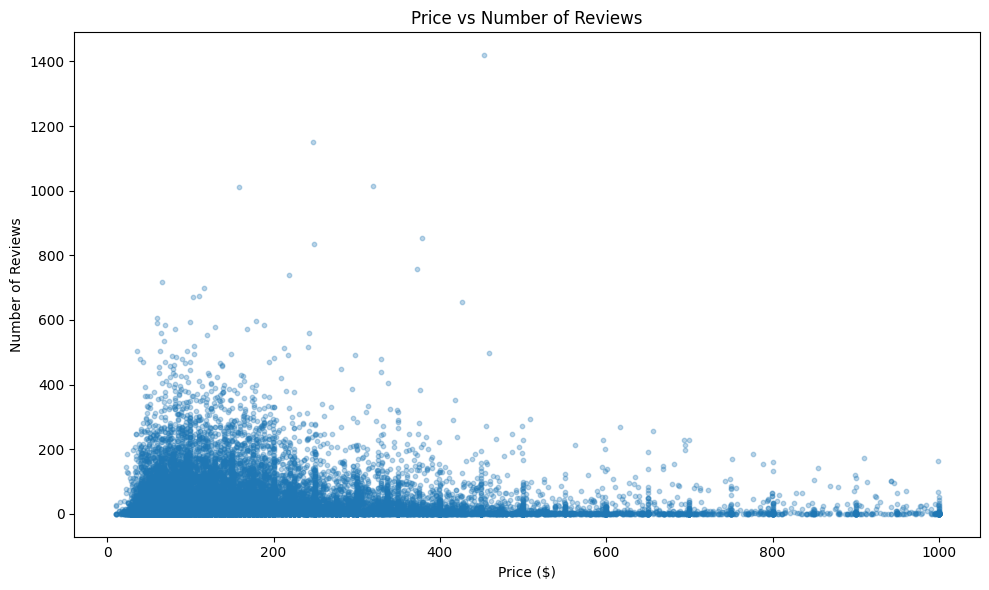


Correlation between Price and Number of Reviews: -0.035


In [55]:
# Price vs Reviewss correlation
plt.figure(figsize=(10, 6))
plt.scatter(df['price'], df['number_of_reviews'], alpha=0.3, s=10)
plt.xlabel('Price ($)')
plt.ylabel('Number of Reviews')
plt.title('Price vs Number of Reviews')
plt.tight_layout()
output_dir = base / 'output'
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'price_vs_reviews.png', dpi=300)
plt.show()
correlation = df['price'].corr(df['number_of_reviews'])
print(f"\nCorrelation between Price and Number of Reviews: {correlation:.3f}")


In [56]:
# Summary report Dataframe
summary_report = pd.DataFrame({
    'Metric': [
        'Total Listings',
        'Average Price per Night',
        'Median Price per Night',
        'Average Monthly Cost (Estimated)',
        'Most Common Room Type',
        'Most Popular Borough',
        'Average reviews per listing',
        'Average Availability (days/year)',
    ],
    'Value': [
        f"{len(df):,}",
        f"${avg_price:.2f}",
        f"${df['price'].median():.2f}",
        f"${avg_monthly_cost:.2f}",
        df['room_type'].mode()[0],
        df['neighbourhood_group_cleansed'].value_counts().index[0],
        f"{df['number_of_reviews'].mean():.1f}",
        f"{df['availability_365'].mean():.1f}",
    ]
})
print("\nSummary Report:")
print (summary_report.to_string(index=False))


Summary Report:
                          Metric           Value
                  Total Listings          36,970
         Average Price per Night         $167.66
          Median Price per Night         $125.00
Average Monthly Cost (Estimated)        $1945.09
           Most Common Room Type Entire home/apt
            Most Popular Borough       Manhattan
     Average reviews per listing            26.5
Average Availability (days/year)           119.0


In [57]:
# Save summary report to CSV
summary_report.to_csv(output_dir / 'summary_report.csv', index=False)